# Notebook 04 — Surplus Allocation

**Purpose:** Distribute the grand coalition's net surplus $v(S)$ among all farmers
using five allocation mechanisms and compare them along stability, fairness,
and smallholder-protection dimensions.

---
**Reads:**
- `data/processed/optimization_inputs.pkl`
- `data/processed/standalone_values.pkl`
- `data/processed/characteristic_function.pkl`

**Mechanisms implemented (all using Gurobi for LP steps):**

| # | Mechanism | Core stable? | Unique? | Complexity |
|---|-----------|-------------|---------|------------|
| 1 | Core / Least Core | Maximal | Partial | Single LP |
| 2 | Nucleolus | Guaranteed (if core non-empty) | Always | Sequence of LPs |
| 3 | Shapley Value | Not guaranteed | Always | O(2^N) arithmetic |
| 4 | Equal Split | Not guaranteed | Always | O(1) |
| 5 | Proportional Split | Not guaranteed | Always | O(N) |

---
### Notation
- $S$ — grand coalition (all farmers)
- $v(S)$ — grand coalition value from Notebook 03
- $\tilde{v}(\{i\})$ — farmer $i$'s standalone value from Notebook 02
- $x_i$ — allocation (payoff) to farmer $i$
- $e(T, \mathbf{x}) = v(T) - \sum_{i \in T} x_i$ — excess of coalition $T$ (its incentive to defect)

## 0. Imports and configuration

In [1]:
import sys
import pickle
import time
import warnings
from pathlib import Path
from itertools import chain, combinations
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import gurobipy as gp
from gurobipy import GRB

sys.path.insert(0, str(Path.cwd()))
import config



## 1. Load all inputs

In [2]:
# ── Optimization inputs ───────────────────────────────────────────────────────
with open(config.INPUTS_PKL, "rb") as f:
    inp = pickle.load(f)

practice_names = inp["practice_names"]

# ── Standalone values (NB02) ──────────────────────────────────────────────────
with open(config.STANDALONE_PKL, "rb") as f:
    standalone_values = pickle.load(f)

# ── Characteristic function (NB03) ───────────────────────────────────────────
with open(config.CHARACTERISTIC_FN_PKL, "rb") as f:
    cf_data = pickle.load(f)

char_fn    = cf_data["characteristic_function"]   # frozenset[str] -> float
gc_key     = cf_data["grand_coalition_key"]        # frozenset of all farmer IDs
v_gc       = cf_data["grand_coalition_value"]      # float
gc_portf   = cf_data["grand_coalition_portfolios"] # fid -> [practice_idx]
farmer_ids = cf_data["farmer_ids"]                 # ordered list of fid strings
N          = len(farmer_ids)

# Ordered standalone values and farm sizes (same order as farmer_ids)
sv_vec   = np.array([standalone_values[fid]["standalone_value"]    for fid in farmer_ids])
fs_vec   = np.array([standalone_values[fid]["farm_size"]           for fid in farmer_ids])
seq_gc   = np.array([
    standalone_values[fid]["farm_size"]
    * sum(
        inp["practices"].set_index("Practice").loc[practice_names[j], "Net_CSP_base"]
        for j in gc_portf.get(fid, [])
    )
    if gc_portf.get(fid)
    else 0.0
    for fid in farmer_ids
])  # tCO2/season per farmer in grand coalition

print(f"Grand coalition: {N} farmers")
print(f"v(Grand)       : {v_gc:,.0f} INR")
print(f"Sum of ṽ({{i}}) : {sv_vec.sum():,.0f} INR")
print(f"Coalition surplus above standalone sum: {v_gc - sv_vec.sum():,.0f} INR")

Grand coalition: 15 farmers
v(Grand)       : 1,499,422 INR
Sum of ṽ({i}) : 0 INR
Coalition surplus above standalone sum: 1,499,422 INR


## 2. Shared LP infrastructure

All LP-based mechanisms (core check, least core, nucleolus) share the same
constraint matrix.  We pre-build it once here.

### Constraint matrix $A$ and right-hand side $b$

For every non-empty proper sub-coalition $T \subsetneq S$:
$$\sum_{i \in T} x_i \geq v(T)$$
which in matrix form is $A \mathbf{x} \geq \mathbf{b}$ with
$A_{T,i} = 1$ if $i \in T$, else $0$, and $b_T = v(T)$.

In [3]:
# ── Build (A, b) for all non-empty proper sub-coalitions ─────────────────────
# fid_to_idx: farmer ID string -> integer index into x vector
fid_to_idx = {fid: i for i, fid in enumerate(farmer_ids)}

# All non-empty subsets of {0,...,N-1}
def powerset_indices(n: int):
    """Yield all non-empty proper subsets of {0,...,n-1} as sorted tuples."""
    rng = range(n)
    for r in range(1, n):   # r = 1 to n-1: proper subsets only
        for combo in combinations(rng, r):
            yield combo

# For each sub-coalition: store (row_index_tuple, v_value)
# Index tuples are integer indices into the farmer_ids list.
sub_coalitions: List[Tuple[tuple, float]] = []

for idx_tuple in powerset_indices(N):
    fid_set   = frozenset(farmer_ids[i] for i in idx_tuple)
    v_T       = char_fn.get(fid_set, 0.0)
    sub_coalitions.append((idx_tuple, v_T))

M_constr = len(sub_coalitions)   # number of sub-coalition constraints

# Build dense A matrix and b vector
A_sub = np.zeros((M_constr, N), dtype=float)
b_sub = np.zeros(M_constr,      dtype=float)

for row, (idx_tuple, v_T) in enumerate(sub_coalitions):
    for i in idx_tuple:
        A_sub[row, i] = 1.0
    b_sub[row] = v_T

print(f"Sub-coalition constraints: {M_constr:,}")
print(f"  (= 2^{N} - 2 = {2**N - 2:,}  non-empty proper subsets)")

Sub-coalition constraints: 32,766
  (= 2^15 - 2 = 32,766  non-empty proper subsets)


## 3. Mechanism 1 — Core check and Least Core

### 3a. Core check (ε = 0)

Solve:
$$\sum_i x_i = v(S), \quad x_i \geq \tilde{v}(\{i\}), \quad \sum_{i\in T} x_i \geq v(T) \; \forall T \subsetneq S$$

If feasible the core is non-empty and any feasible point is a core allocation.

In [4]:
def _make_env(silent: bool = True) -> gp.Env:
    env = gp.Env(empty=True)
    env.setParam("OutputFlag", 0 if silent else 1)
    env.setParam("TimeLimit",  config.GUROBI_TIME_LIMIT)
    env.start()
    return env


def check_core_and_least_core(
    v_grand: float,
    sv: np.ndarray,
    A: np.ndarray,
    b: np.ndarray,
    n: int,
) -> Dict:
    """
    Phase 1: check if the core is non-empty (ε = 0 feasibility test).
    Phase 2: if infeasible, minimise ε (least core).

    Returns
    -------
    dict with keys:
        core_nonempty   : bool
        epsilon_star    : float   (0 if core non-empty)
        allocation      : np.ndarray of shape (n,)  — the x vector
        stable          : bool  (True if ε* ≤ EPSILON_MAX)
    """
    # ── Phase 1: feasibility check at ε = 0 ──────────────────────────────────
    env   = _make_env()
    model = gp.Model("core_check", env=env)
    x     = model.addVars(n, lb=-GRB.INFINITY, name="x")

    # Efficiency
    model.addConstr(gp.quicksum(x[i] for i in range(n)) == v_grand, "efficiency")

    # Individual rationality
    for i in range(n):
        model.addConstr(x[i] >= sv[i], f"IR_{i}")

    # Sub-coalition rationality (no slack)
    for row in range(len(b)):
        lhs = gp.quicksum(A[row, i] * x[i] for i in range(n) if A[row, i] != 0)
        model.addConstr(lhs >= b[row], f"core_{row}")

    # Feasibility check — any objective
    model.setObjective(0, GRB.MINIMIZE)
    model.optimize()

    if model.Status == GRB.OPTIMAL:
        alloc = np.array([x[i].X for i in range(n)])
        model.dispose()
        env.dispose()
        return {
            "core_nonempty" : True,
            "epsilon_star"  : 0.0,
            "allocation"    : alloc,
            "stable"        : True,
        }

    model.dispose()
    env.dispose()

    # ── Phase 2: core is empty — compute least core ───────────────────────────
    env   = _make_env()
    model = gp.Model("least_core", env=env)
    x     = model.addVars(n, lb=-GRB.INFINITY, name="x")
    eps   = model.addVar(lb=0.0, name="epsilon")

    # Efficiency
    model.addConstr(gp.quicksum(x[i] for i in range(n)) == v_grand, "efficiency")

    # Individual rationality (never relaxed — IR is a hard floor)
    for i in range(n):
        model.addConstr(x[i] >= sv[i], f"IR_{i}")

    # Relaxed sub-coalition constraints
    for row in range(len(b)):
        lhs = gp.quicksum(A[row, i] * x[i] for i in range(n) if A[row, i] != 0)
        model.addConstr(lhs >= b[row] - eps, f"lc_{row}")

    model.setObjective(eps, GRB.MINIMIZE)
    model.optimize()

    if model.Status == GRB.OPTIMAL:
        alloc  = np.array([x[i].X for i in range(n)])
        e_star = eps.X
        model.dispose()
        env.dispose()
        return {
            "core_nonempty" : False,
            "epsilon_star"  : e_star,
            "allocation"    : alloc,
            "stable"        : e_star <= config.EPSILON_MAX,
        }

    status_code = model.Status   # capture before dispose frees the object
    model.dispose()
    env.dispose()
    raise RuntimeError(f"Least core LP failed with status {status_code}")


print("Running core check / least core...")
t0 = time.perf_counter()
lc_result = check_core_and_least_core(v_gc, sv_vec, A_sub, b_sub, N)
print(f"Done in {time.perf_counter()-t0:.2f} s")
print()
print(f"Core non-empty : {lc_result['core_nonempty']}")
print(f"ε*             : {lc_result['epsilon_star']:,.4f} INR")
print(f"Stable         : {lc_result['stable']}  "
      f"(threshold ε_max = {config.EPSILON_MAX})")

Running core check / least core...
Done in 3.31 s

Core non-empty : True
ε*             : 0.0000 INR
Stable         : True  (threshold ε_max = 0.0001)


## 4. Mechanism 2 — Nucleolus

The nucleolus lexicographically minimises the sorted vector of sub-coalition
excesses $e(T, \mathbf{x}) = v(T) - \sum_{i \in T} x_i$.

**Algorithm (sequence of LPs):**

1. Solve the least core LP to obtain $\varepsilon_1^*$ (maximum excess minimised).
2. Fix all constraints that are tight at $\varepsilon_1^*$ (within tolerance); remove
   them from the active constraint set.
3. Minimise the maximum excess over the *remaining* constraints, with the fixed
   constraints enforced as equalities.
4. Repeat until all constraints are fixed or the allocation is unique.

Because each LP is a small $N$-variable LP (for 15 farmers, $N=15$), this
converges in at most $2^N - 2$ iterations but typically far fewer.

In [5]:
def compute_nucleolus(
    v_grand: float,
    sv: np.ndarray,
    A: np.ndarray,
    b: np.ndarray,
    n: int,
    tol: float = 1e-6,
    max_iter: int = 200,
    verbose: bool = False,
) -> Dict:
    """
    Compute the nucleolus via iterated least-core LPs (Maschler-Peleg-Shapley
    sequential reduction).

    At each iteration:
      - Minimise ε (the maximum excess of the *active* constraints)
      - Identify constraints whose excess equals ε* (within tol)
      - Pin those constraints at equality in all future iterations
      - Repeat on the remaining active constraints

    Returns
    -------
    dict with keys:
        allocation  : np.ndarray (n,)
        n_iterations: int
        epsilon_sequence: list[float]  — ε* at each iteration
    """
    M = len(b)   # total number of sub-coalition constraints

    # active[row] = True means this constraint is still being minimised.
    # Once pinned it becomes an equality and is no longer active.
    active   = np.ones(M, dtype=bool)
    # pinned_eps[row] = ε* value at which this constraint was pinned
    pinned_eps = np.full(M, np.nan)

    eps_sequence = []
    x_solution   = None

    for iteration in range(max_iter):
        n_active = active.sum()
        if n_active == 0:
            break

        env   = _make_env()
        model = gp.Model(f"nucleolus_iter_{iteration}", env=env)
        x     = model.addVars(n, lb=-GRB.INFINITY, name="x")
        eps   = model.addVar(lb=-GRB.INFINITY, name="eps")  # can be negative

        # Efficiency
        model.addConstr(
            gp.quicksum(x[i] for i in range(n)) == v_grand,
            "efficiency"
        )

        # Individual rationality (hard floor, never relaxed)
        for i in range(n):
            model.addConstr(x[i] >= sv[i], f"IR_{i}")

        # Previously pinned constraints: fix as equalities
        #   excess(T, x) = v(T) - Σ x_i = pinned_eps[row]
        #   → Σ_{i∈T} x_i = v(T) - pinned_eps[row]
        for row in range(M):
            if not active[row] and not np.isnan(pinned_eps[row]):
                lhs = gp.quicksum(
                    A[row, i] * x[i] for i in range(n) if A[row, i] != 0
                )
                rhs = b[row] - pinned_eps[row]
                model.addConstr(lhs == rhs, f"pinned_{row}")

        # Active constraints: excess ≤ ε
        #   v(T) - Σ x_i ≤ ε  →  Σ x_i ≥ v(T) - ε
        for row in range(M):
            if active[row]:
                lhs = gp.quicksum(
                    A[row, i] * x[i] for i in range(n) if A[row, i] != 0
                )
                model.addConstr(lhs >= b[row] - eps, f"active_{row}")

        model.setObjective(eps, GRB.MINIMIZE)
        model.optimize()

        if model.Status != GRB.OPTIMAL:
            status_code = model.Status   # capture before dispose frees the object
            model.dispose()
            env.dispose()
            warnings.warn(
                f"Nucleolus iteration {iteration} returned status {status_code}. "
                "Returning best available allocation."
            )
            break

        x_vals  = np.array([x[i].X for i in range(n)])
        eps_val = eps.X
        eps_sequence.append(eps_val)

        if verbose:
            print(f"  Iter {iteration:3d}: ε* = {eps_val:+.4f}  "
                  f"active constraints = {n_active}")

        # Pin all active constraints whose excess equals ε* (within tolerance)
        new_pinned = 0
        for row in range(M):
            if active[row]:
                # Compute excess for this constraint at current solution
                allocation_sum = float(A[row] @ x_vals)
                excess = b[row] - allocation_sum
                if abs(excess - eps_val) <= tol:
                    active[row]     = False
                    pinned_eps[row] = eps_val
                    new_pinned     += 1

        x_solution = x_vals
        model.dispose()
        env.dispose()

        if verbose:
            print(f"           pinned {new_pinned} constraints this iteration")

        # Convergence: no more active constraints
        if active.sum() == 0:
            break

    return {
        "allocation"      : x_solution,
        "n_iterations"    : len(eps_sequence),
        "epsilon_sequence": eps_sequence,
    }


print("Running nucleolus (sequence of LPs)...")
t0 = time.perf_counter()
nuc_result = compute_nucleolus(
    v_gc, sv_vec, A_sub, b_sub, N,
    tol=1e-6, max_iter=200, verbose=True
)
print(f"\nDone in {time.perf_counter()-t0:.2f} s")
print(f"Iterations        : {nuc_result['n_iterations']}")
print(f"ε sequence        : {[f'{e:.4f}' for e in nuc_result['epsilon_sequence']]}")

Running nucleolus (sequence of LPs)...
  Iter   0: ε* = -703.0627  active constraints = 32766
           pinned 15 constraints this iteration
  Iter   1: ε* = -1355.2537  active constraints = 32751
           pinned 1 constraints this iteration
  Iter   2: ε* = -1358.4634  active constraints = 32750
           pinned 1 constraints this iteration
  Iter   3: ε* = -1363.3877  active constraints = 32749
           pinned 1 constraints this iteration
  Iter   4: ε* = -1364.7797  active constraints = 32748
           pinned 1 constraints this iteration
  Iter   5: ε* = -1367.3614  active constraints = 32747
           pinned 1 constraints this iteration
  Iter   6: ε* = -1371.3618  active constraints = 32746
           pinned 1 constraints this iteration
  Iter   7: ε* = -1372.4928  active constraints = 32745
           pinned 1 constraints this iteration
  Iter   8: ε* = -1373.5504  active constraints = 32744
           pinned 1 constraints this iteration
  Iter   9: ε* = -1374.6099  activ

/var/folders/2v/pnt0bgkj0rz4f85np7_clwxm0000gn/T/ipykernel_84418/2220704185.py:86: UserWarning: Nucleolus iteration 97 returned status 3. Returning best available allocation.
  warnings.warn(


## 5. Mechanism 3 — Shapley Value

Computed directly from the characteristic function table with no new Gurobi solves.

$$\phi_i = \sum_{T \subseteq S \setminus \{i\}} 
\frac{|T|!\;(|S|-|T|-1)!}{|S|!}\;\bigl[v(T\cup\{i\}) - v(T)\bigr]$$

In [6]:
import math

def compute_shapley(
    farmer_ids: List[str],
    char_fn: Dict[frozenset, float],
) -> np.ndarray:
    """
    Exact Shapley value from the precomputed characteristic function table.

    For N=15, this requires iterating over 2^14 = 16,384 subsets per player,
    i.e. 15 × 16,384 = 245,760 lookups — fast pure-Python arithmetic.

    Returns
    -------
    np.ndarray of shape (N,)
    """
    n          = len(farmer_ids)
    factorial_n = math.factorial(n)
    shapley    = np.zeros(n)

    fid_set_all = set(farmer_ids)

    for idx_i, fid_i in enumerate(farmer_ids):
        others = [fid for fid in farmer_ids if fid != fid_i]
        contribution = 0.0

        # Iterate over all subsets T ⊆ S\{i}
        for r in range(len(others) + 1):
            weight = (
                math.factorial(r) * math.factorial(n - r - 1)
                / factorial_n
            )
            for T_tuple in combinations(others, r):
                T_set     = frozenset(T_tuple)
                T_plus_i  = frozenset(T_tuple) | frozenset([fid_i])
                v_T       = char_fn.get(T_set,    0.0)   # empty set → 0
                v_T_plus_i = char_fn.get(T_plus_i, 0.0)
                marginal   = v_T_plus_i - v_T
                contribution += weight * marginal

        shapley[idx_i] = contribution

    return shapley


print("Computing Shapley values...")
t0 = time.perf_counter()
shapley_alloc = compute_shapley(farmer_ids, char_fn)
print(f"Done in {time.perf_counter()-t0:.2f} s")

# Verify efficiency: Σ φ_i = v(S)
shapley_sum = shapley_alloc.sum()
print(f"Σ φ_i = {shapley_sum:,.2f}  (v(Grand) = {v_gc:,.2f})  "
      f"diff = {abs(shapley_sum - v_gc):.4f}")
assert abs(shapley_sum - v_gc) < 1.0, "Shapley efficiency violated!"
print("Efficiency check: PASS ✓")

Computing Shapley values...
Done in 0.29 s
Σ φ_i = 1,499,421.69  (v(Grand) = 1,499,421.69)  diff = 0.0000
Efficiency check: PASS ✓


## 6. Mechanisms 4 & 5 — Equal Split and Proportional Split

In [7]:
# ── Equal split ───────────────────────────────────────────────────────────────
equal_alloc = np.full(N, v_gc / N)

# ── Proportional split by sequestration contribution ─────────────────────────
# x_i = (FS_i * CSP_i(Π_i^co)) / Σ_j(FS_j * CSP_j(Π_j^co)) * v(S)
# seq_gc[i] was computed in cell 1 (tCO2/season for farmer i in grand coalition)
seq_total = seq_gc.sum()
if seq_total > 0:
    prop_alloc = (seq_gc / seq_total) * v_gc
else:
    # Fallback to equal split if no sequestration (degenerate case)
    prop_alloc = equal_alloc.copy()
    warnings.warn("Total sequestration is zero — proportional split falls back to equal split.")

print(f"Equal split per farmer : {v_gc/N:,.0f} INR")
print(f"Total seq. (grand coal): {seq_total:.3f} tCO2/season")
print(f"Proportional split range: [{prop_alloc.min():,.0f}, {prop_alloc.max():,.0f}] INR")

Equal split per farmer : 99,961 INR
Total seq. (grand coal): 165.087 tCO2/season
Proportional split range: [23,746, 211,457] INR


## 7. Post-hoc stability verification for all mechanisms

In [8]:
def verify_allocation(
    alloc: np.ndarray,
    name: str,
    v_grand: float,
    sv: np.ndarray,
    A: np.ndarray,
    b: np.ndarray,
    n: int,
    tol: float = 1.0,
) -> Dict:
    """
    Check efficiency, individual rationality, and core constraints
    for a given allocation vector.

    Returns a summary dict with counts of violations.
    """
    results = {"mechanism": name}

    # Efficiency
    eff_diff = abs(alloc.sum() - v_grand)
    results["efficiency_ok"]   = eff_diff <= tol
    results["efficiency_diff"] = eff_diff

    # Individual rationality
    ir_violations  = [i for i in range(n) if alloc[i] < sv[i] - tol]
    results["IR_ok"]            = len(ir_violations) == 0
    results["IR_violations"]    = ir_violations

    # Core constraints
    core_violations = []
    max_excess      = -np.inf
    for row in range(len(b)):
        alloc_sum = float(A[row] @ alloc)
        excess    = b[row] - alloc_sum   # positive excess = sub-coalition wants to defect
        max_excess = max(max_excess, excess)
        if excess > tol:
            core_violations.append(row)

    results["core_ok"]             = len(core_violations) == 0
    results["n_core_violations"]   = len(core_violations)
    results["max_excess"]          = max_excess

    return results


mechanisms = {
    "Least Core"   : lc_result["allocation"],
    "Nucleolus"    : nuc_result["allocation"],
    "Shapley"      : shapley_alloc,
    "Equal Split"  : equal_alloc,
    "Proportional" : prop_alloc,
}

verification_results = {}
for name, alloc in mechanisms.items():
    if alloc is None:
        print(f"  {name:<15}: allocation is None — skipped")
        continue
    vr = verify_allocation(alloc, name, v_gc, sv_vec, A_sub, b_sub, N)
    verification_results[name] = vr

print(f"{'Mechanism':<15}  {'Efficient':>9}  {'IR OK':>7}  "
      f"{'Core OK':>8}  {'#Violations':>12}  {'Max Excess':>12}")
print("-" * 75)
for name, vr in verification_results.items():
    print(
        f"{name:<15}  "
        f"{'YES' if vr['efficiency_ok'] else 'NO':>9}  "
        f"{'YES' if vr['IR_ok'] else 'NO':>7}  "
        f"{'YES' if vr['core_ok'] else 'NO':>8}  "
        f"{vr['n_core_violations']:>12,}  "
        f"{vr['max_excess']:>12.2f}"
    )

# Report any IR violations by farmer
print()
for name, vr in verification_results.items():
    if not vr["IR_ok"]:
        fids = [farmer_ids[i] for i in vr["IR_violations"]]
        print(f"  IR violations in {name}: {fids}")

Mechanism        Efficient    IR OK   Core OK   #Violations    Max Excess
---------------------------------------------------------------------------
Least Core             YES      YES       YES             0          0.00
Nucleolus              YES      YES       YES             0       -703.06
Shapley                YES      YES        NO         9,734      50498.85
Equal Split            YES      YES        NO        15,237     354039.63
Proportional           YES      YES        NO            21        504.01



## 8. Main comparison table

In [9]:
rows = []
for i, fid in enumerate(farmer_ids):
    row = {
        "Farmer"       : fid,
        "Farm_ha"      : round(fs_vec[i], 2),
        "Standalone"   : round(sv_vec[i], 0),
        "Least_Core"   : round(mechanisms["Least Core"][i],   0) if mechanisms["Least Core"]   is not None else None,
        "Nucleolus"    : round(mechanisms["Nucleolus"][i],    0) if mechanisms["Nucleolus"]    is not None else None,
        "Shapley"      : round(mechanisms["Shapley"][i],      0),
        "Equal_Split"  : round(mechanisms["Equal Split"][i],  0),
        "Proportional" : round(mechanisms["Proportional"][i], 0),
    }
    rows.append(row)

df_alloc = pd.DataFrame(rows)

# Mark IR violations with an asterisk
for mech_col, mech_name in [
    ("Least_Core",   "Least Core"),
    ("Nucleolus",    "Nucleolus"),
    ("Shapley",      "Shapley"),
    ("Equal_Split",  "Equal Split"),
    ("Proportional", "Proportional"),
]:
    vr = verification_results.get(mech_name, {})
    ir_bad = set(vr.get("IR_violations", []))
    if ir_bad:
        df_alloc[mech_col] = df_alloc[mech_col].astype(str)
        for idx_i in ir_bad:
            df_alloc.at[idx_i, mech_col] = str(df_alloc.at[idx_i, mech_col]) + " *"

pd.set_option("display.max_columns", None)
pd.set_option("display.width",       180)
display(df_alloc)

print()
print("* = individual rationality violated (farmer would be better off solo)")
print()

# Footer: column totals
print("Column totals (should all equal v(Grand) for efficient mechanisms):")
for col in ["Standalone", "Least_Core", "Nucleolus", "Shapley", "Equal_Split", "Proportional"]:
    try:
        total = pd.to_numeric(df_alloc[col].str.replace(" *", "", regex=False), errors="coerce").sum()
        print(f"  {col:<15}: {total:>15,.0f} INR")
    except Exception:
        pass

,Farmer,Farm_ha,Standalone,Least_Core,Nucleolus,Shapley,Equal_Split,Proportional
0,F0001,0.82,0.0,93343.0,92640.0,94135.0,99961.0,92724.0
1,F0002,0.21,0.0,23481.0,22831.0,15391.0,99961.0,23746.0
2,F0003,1.28,0.0,145890.0,145278.0,157264.0,99961.0,144741.0
3,F0004,1.55,0.0,176713.0,176173.0,180141.0,99961.0,175272.0
4,F0005,0.69,0.0,78373.0,77763.0,74668.0,99961.0,78024.0
5,F0006,0.44,0.0,49774.0,49153.0,40844.0,99961.0,49755.0
6,F0007,0.60,0.0,68069.0,67463.0,62414.0,99961.0,67847.0
7,F0008,0.26,0.0,29216.0,28553.0,20568.0,99961.0,29400.0
8,F0009,1.46,0.0,166438.0,165875.0,169873.0,99961.0,165095.0
9,F0010,1.32,0.0,150541.0,149856.0,153417.0,99961.0,149264.0



* = individual rationality violated (farmer would be better off solo)

Column totals (should all equal v(Grand) for efficient mechanisms):


## 9. Excess analysis — who wants to defect and under which mechanism?

In [10]:
def top_excess_coalitions(
    alloc: np.ndarray,
    A: np.ndarray,
    b: np.ndarray,
    sub_coalitions: list,
    farmer_ids: list,
    top_k: int = 10,
) -> pd.DataFrame:
    """
    Return the top-k sub-coalitions with highest excess
    (most likely to defect) under this allocation.
    """
    excesses = []
    for row, (idx_tuple, v_T) in enumerate(sub_coalitions):
        alloc_sum = float(A[row] @ alloc)
        excess    = v_T - alloc_sum
        fids      = [farmer_ids[i] for i in idx_tuple]
        excesses.append({
            "coalition"   : ", ".join(fids),
            "size"        : len(idx_tuple),
            "v_T"         : round(v_T, 0),
            "alloc_sum"   : round(alloc_sum, 0),
            "excess"      : round(excess, 2),
        })
    df = pd.DataFrame(excesses).sort_values("excess", ascending=False).head(top_k)
    return df.reset_index(drop=True)


for name in ["Least Core", "Nucleolus", "Shapley"]:
    alloc = mechanisms[name]
    if alloc is None:
        continue
    df_ex = top_excess_coalitions(alloc, A_sub, b_sub, sub_coalitions, farmer_ids, top_k=5)
    print(f"\n{'='*60}")
    print(f"Top-5 highest-excess sub-coalitions under {name}")
    print(f"{'='*60}")
    display(df_ex)


Top-5 highest-excess sub-coalitions under Least Core


,coalition,size,v_T,alloc_sum,excess
0,"F0002, F0003, F0004, F0005, F0006, F0007, F000...",14,1406079.0,1406079.0,0.0
1,"F0002, F0003, F0004, F0005, F0006, F0007, F000...",13,1255538.0,1255538.0,0.0
2,"F0005, F0011, F0012, F0013",4,466646.0,466646.0,0.0
3,"F0007, F0012, F0013, F0015",4,482632.0,482632.0,0.0
4,"F0007, F0009, F0012",3,438603.0,438603.0,0.0



Top-5 highest-excess sub-coalitions under Nucleolus


,coalition,size,v_T,alloc_sum,excess
0,"F0002, F0003, F0004, F0005, F0006, F0007, F000...",14,1406079.0,1406782.0,-703.06
1,"F0001, F0002, F0003, F0004, F0005, F0006, F000...",14,1470166.0,1470869.0,-703.06
2,"F0001, F0002, F0003, F0004, F0005, F0006, F000...",14,1399213.0,1399916.0,-703.06
3,"F0001, F0002, F0003, F0004, F0005, F0006, F000...",14,1470166.0,1470869.0,-703.06
4,"F0001, F0002, F0003, F0004, F0005, F0006, F000...",14,1388914.0,1389617.0,-703.06



Top-5 highest-excess sub-coalitions under Shapley


,coalition,size,v_T,alloc_sum,excess
0,"F0001, F0002, F0005, F0006, F0007, F0008, F001...",10,646409.0,595910.0,50498.85
1,"F0002, F0005, F0006, F0007, F0008, F0010, F001...",10,703547.0,655191.0,48355.43
2,"F0002, F0004, F0005, F0006, F0007, F0008, F001...",10,729834.0,681915.0,47918.30
3,"F0002, F0005, F0006, F0007, F0008, F0009, F001...",10,719547.0,671647.0,47900.47
4,"F0001, F0002, F0005, F0006, F0007, F0008, F001...",11,796774.0,749327.0,47447.00


## 10. Visualisations

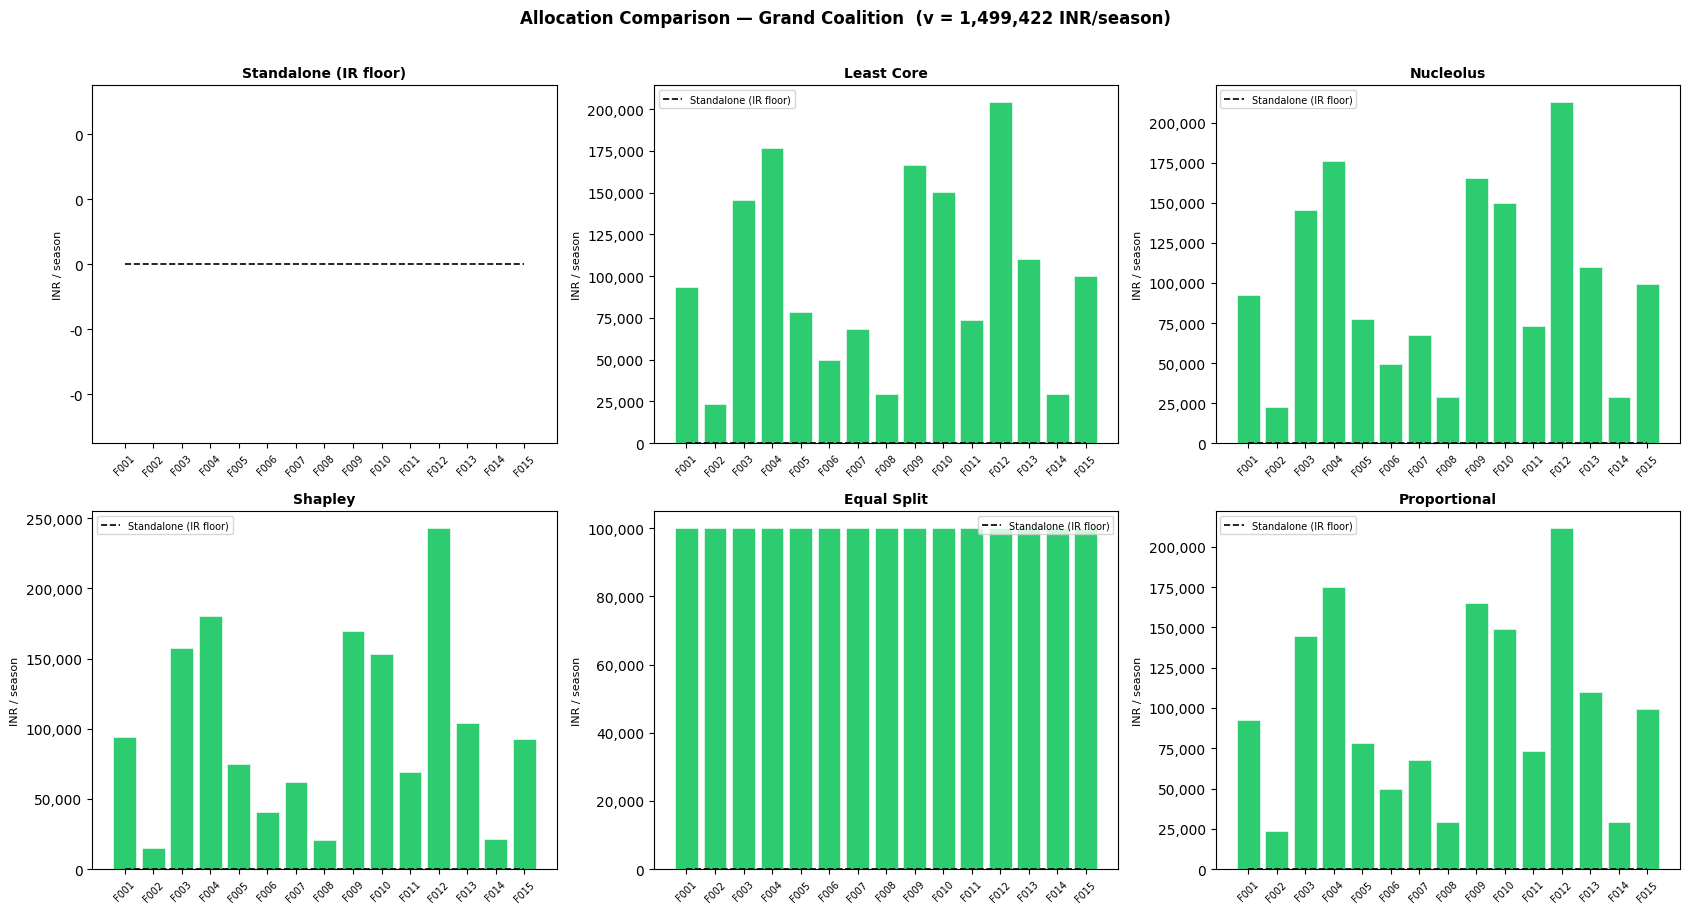

Figure 1 saved.


In [11]:
# ── Plot 1: Allocation comparison across mechanisms ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

plot_order = [
    ("Standalone (IR floor)", sv_vec),
    ("Least Core",            lc_result["allocation"]),
    ("Nucleolus",             nuc_result["allocation"]),
    ("Shapley",               shapley_alloc),
    ("Equal Split",           equal_alloc),
    ("Proportional",          prop_alloc),
]

x_ticks = range(N)
fid_labels = [fid.replace("F0", "F") for fid in farmer_ids]

for ax, (title, alloc) in zip(axes, plot_order):
    if alloc is None:
        ax.set_title(f"{title}\n(unavailable)", fontsize=9)
        ax.axis("off")
        continue

    colors = ["#2ecc71" if alloc[i] >= sv_vec[i] else "#e74c3c" for i in range(N)]
    ax.bar(x_ticks, alloc, color=colors, edgecolor="white", linewidth=0.4)
    ax.step(x_ticks, sv_vec, where="mid", color="black",
            linewidth=1.2, linestyle="--", label="Standalone (IR floor)")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(fid_labels, rotation=45, fontsize=7)
    ax.set_ylabel("INR / season", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    if title != "Standalone (IR floor)":
        ax.legend(fontsize=7)

fig.suptitle(
    f"Allocation Comparison — Grand Coalition  (v = {v_gc:,.0f} INR/season)",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(
    f"{config.PROCESSED_DIR}/nb04_allocation_comparison.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Figure 1 saved.")

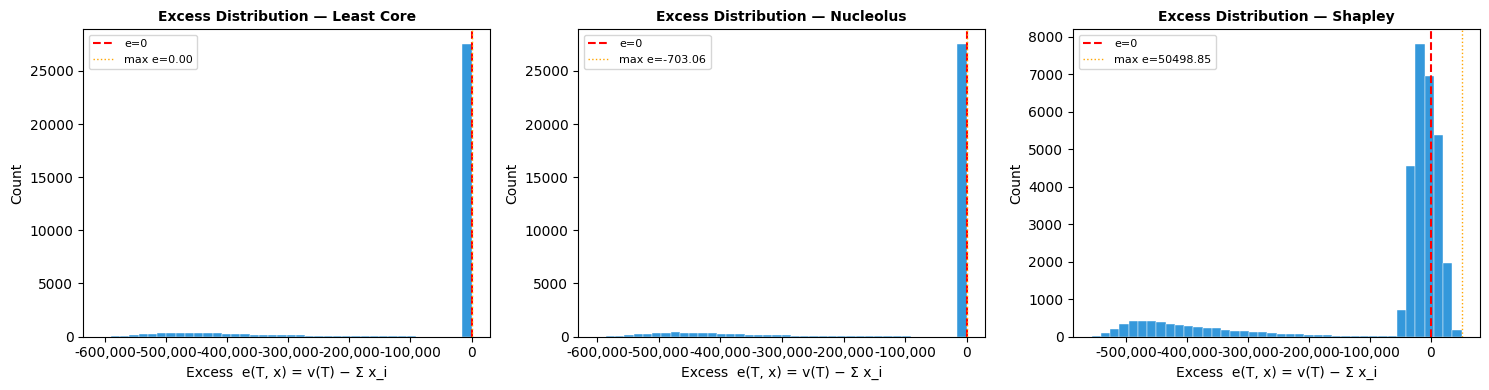

Figure 2 saved.


In [12]:
# ── Plot 2: Excess distribution under each mechanism ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
mech_plot = [("Least Core", lc_result["allocation"]),
             ("Nucleolus",  nuc_result["allocation"]),
             ("Shapley",    shapley_alloc)]

for ax, (name, alloc) in zip(axes, mech_plot):
    if alloc is None:
        ax.set_title(f"{name}\n(unavailable)")
        ax.axis("off")
        continue
    excesses = [b_sub[row] - float(A_sub[row] @ alloc) for row in range(len(b_sub))]
    ax.hist(excesses, bins=40, color="#3498db", edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="red",   linewidth=1.5, linestyle="--", label="e=0")
    ax.axvline(max(excesses), color="orange", linewidth=1, linestyle=":",
               label=f"max e={max(excesses):.2f}")
    ax.set_title(f"Excess Distribution — {name}", fontweight="bold", fontsize=10)
    ax.set_xlabel("Excess  e(T, x) = v(T) − Σ x_i")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig(
    f"{config.PROCESSED_DIR}/nb04_excess_distributions.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Figure 2 saved.")

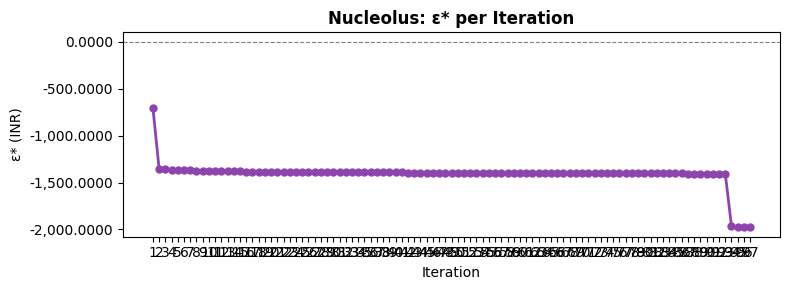

Figure 3 saved.


In [13]:
# ── Plot 3: Nucleolus ε sequence (convergence trace) ─────────────────────────
if nuc_result["n_iterations"] > 1:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(
        range(1, nuc_result["n_iterations"] + 1),
        nuc_result["epsilon_sequence"],
        "o-", color="#8e44ad", linewidth=2, markersize=5
    )
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title("Nucleolus: ε* per Iteration", fontweight="bold")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("ε* (INR)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.4f}"))
    ax.set_xticks(range(1, nuc_result["n_iterations"] + 1))
    plt.tight_layout()
    plt.savefig(
        f"{config.PROCESSED_DIR}/nb04_nucleolus_convergence.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    print("Figure 3 saved.")

## 11. Summary scorecard

In [14]:
scorecard_rows = []
for name in ["Least Core", "Nucleolus", "Shapley", "Equal Split", "Proportional"]:
    alloc = mechanisms[name]
    vr    = verification_results.get(name, {})
    if alloc is None:
        continue

    # Gini coefficient of the allocation (inequality measure)
    a_sorted = np.sort(alloc)
    n_       = len(a_sorted)
    gini     = (
        2 * np.sum((np.arange(1, n_+1)) * a_sorted) / (n_ * a_sorted.sum()) - (n_+1)/n_
        if a_sorted.sum() > 0 else 0.0
    )

    # Minimum gain above standalone value (smallholder protection metric)
    gain_above_sv = alloc - sv_vec
    min_gain      = gain_above_sv.min()
    min_gain_fid  = farmer_ids[gain_above_sv.argmin()]

    scorecard_rows.append({
        "Mechanism"       : name,
        "Efficient"       : "Yes" if vr.get("efficiency_ok", False) else "No",
        "IR_satisfied"    : "Yes" if vr.get("IR_ok", False) else "No",
        "Core_satisfied"  : "Yes" if vr.get("core_ok", False) else "No",
        "Core_violations" : vr.get("n_core_violations", "N/A"),
        "Max_excess_INR"  : round(vr.get("max_excess", float("nan")), 2),
        "Gini_coeff"      : round(gini, 4),
        "Min_gain_INR"    : round(min_gain, 0),
        "Min_gain_farmer" : min_gain_fid,
    })

df_scorecard = pd.DataFrame(scorecard_rows)
display(df_scorecard)

print()
print("Notes:")
print("  Gini coefficient: 0 = perfectly equal allocation, 1 = maximally unequal")
print("  Min gain INR    : smallest (alloc_i - standalone_i) across all farmers")
print("                    Negative means that farmer would be better off solo")

,Mechanism,Efficient,IR_satisfied,Core_satisfied,Core_violations,Max_excess_INR,Gini_coeff,Min_gain_INR,Min_gain_farmer
0,Least Core,Yes,Yes,Yes,0,0.00,0.3172,23481.0,F0002
1,Nucleolus,Yes,Yes,Yes,0,-703.06,0.3231,22831.0,F0002
2,Shapley,Yes,Yes,No,9734,50498.85,0.3662,15391.0,F0002
3,Equal Split,Yes,Yes,No,15237,354039.63,-0.0000,99961.0,F0001
4,Proportional,Yes,Yes,No,21,504.01,0.3193,23746.0,F0002



Notes:
  Gini coefficient: 0 = perfectly equal allocation, 1 = maximally unequal
  Min gain INR    : smallest (alloc_i - standalone_i) across all farmers
                    Negative means that farmer would be better off solo


## 12. Save allocation results

In [15]:
output = {
    "farmer_ids"       : farmer_ids,
    "standalone_values": sv_vec,
    "v_grand"          : v_gc,
    "allocations": {
        "least_core"   : lc_result["allocation"],
        "nucleolus"    : nuc_result["allocation"],
        "shapley"      : shapley_alloc,
        "equal_split"  : equal_alloc,
        "proportional" : prop_alloc,
    },
    "least_core_meta": {
        "core_nonempty": lc_result["core_nonempty"],
        "epsilon_star" : lc_result["epsilon_star"],
        "stable"       : lc_result["stable"],
    },
    "nucleolus_meta": {
        "n_iterations"    : nuc_result["n_iterations"],
        "epsilon_sequence": nuc_result["epsilon_sequence"],
    },
    "verification"  : verification_results,
    "scorecard_df"  : df_scorecard,
    "allocation_df" : df_alloc,
}

out_path = Path(config.PROCESSED_DIR) / "allocation_results.pkl"
with open(out_path, "wb") as f:
    pickle.dump(output, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved: {out_path.resolve()}")
print()
print("=" * 60)
print("NOTEBOOK 04 COMPLETE")
print("=" * 60)
print(f"  Grand coalition value    : {v_gc:,.0f} INR")
print(f"  Core non-empty           : {lc_result['core_nonempty']}")
print(f"  Least-core ε*            : {lc_result['epsilon_star']:,.4f} INR")
print(f"  Nucleolus iterations     : {nuc_result['n_iterations']}")
print(f"  Output file              : {out_path}")

Saved: /Users/rohitsuresh/Desktop/CGT_Carbon_farming/data/processed/allocation_results.pkl

NOTEBOOK 04 COMPLETE
  Grand coalition value    : 1,499,422 INR
  Core non-empty           : True
  Least-core ε*            : 0.0000 INR
  Nucleolus iterations     : 97
  Output file              : /Users/rohitsuresh/Desktop/CGT_Carbon_farming/data/processed/allocation_results.pkl
